<a href="https://colab.research.google.com/github/MarinaStepanova1709/PythonProject/blob/main/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%D0%A0%D0%B5%D0%B7%D1%8E%D0%BC%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ резюме из HeadHunter
   

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import re

In [15]:
# from google.colab import drive
# drive.mount('/content/drive')

In [16]:
# !pip install pandas
# !pip install matplotlib
# !pip install seaborn
# !pip install plotly

In [17]:
# путь к файлу
# %cd /content/drive/MyDrive/Colab\ Notebooks/ИзиГайд/Итоговый
# import os

# os.path.getsize('hh_database.csv')

# Исследование структуры данных

1. Прочитайте данные с помощью библиотеки Pandas. Совет: перед чтением обратите внимание на разделитель внутри файла.

Файл будем скачивать с Google Drive

In [92]:
# скачать файл в colab - 'hh_database.csv'
!pip install -q gdown

import os
import gdown
import pandas as pd


file_id = '1QKba1gL7WKaK3jVhV7kqpzfU3lDhWfOE'
filename = 'hh_database.csv'

if not os.path.exists(filename):
    gdown.download(
        f'https://drive.google.com/uc?id={file_id}',
        filename,
        quiet=False
    )



In [93]:
# прочитаем файл https://drive.google.com/file/d/1eLsas2hSKy5_lMQWBYodzfowuoamGxDF/view?usp=sharing

file_id = '1eLsas2hSKy5_lMQWBYodzfowuoamGxDF'
filename = 'ExchangeRates.csv'

if not os.path.exists(filename):
    gdown.download(
        f'https://drive.google.com/uc?id={file_id}',
        filename,
        quiet=False
    )

exch_rate = pd.read_csv('ExchangeRates.csv')

In [21]:
df = pd.read_csv('hh_database.csv',sep=';')
df.head()

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
0,"Мужчина , 39 лет , родился 27 ноября 1979",29000 руб.,Системный администратор,"Советск (Калининградская область) , не готов к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...",Опыт работы 16 лет 10 месяцев Август 2010 — п...,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,Неоконченное высшее образование 2000 Балтийск...,16.04.2019 15:59,Имеется собственный автомобиль
1,"Мужчина , 60 лет , родился 20 марта 1959",40000 руб.,Технический писатель,"Королев , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Опыт работы 19 лет 5 месяцев Январь 2000 — по...,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",Высшее образование 1981 Военно-космическая ак...,12.04.2019 08:42,Не указано
2,"Женщина , 36 лет , родилась 12 августа 1982",20000 руб.,Оператор,"Тверь , не готова к переезду , не готова к ком...",полная занятость,полный день,Опыт работы 10 лет 3 месяца Октябрь 2004 — Де...,ПАО Сбербанк,Кассир-операционист,Среднее специальное образование 2002 Профессио...,16.04.2019 08:35,Не указано
3,"Мужчина , 38 лет , родился 25 июня 1980",100000 руб.,Веб-разработчик (HTML / CSS / JS / PHP / базы ...,"Саратов , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, удаленная работа",Опыт работы 18 лет 9 месяцев Август 2017 — Ап...,OpenSoft,Инженер-программист,Высшее образование 2002 Саратовский государст...,08.04.2019 14:23,Не указано
4,"Женщина , 26 лет , родилась 3 марта 1993",140000 руб.,Региональный менеджер по продажам,"Москва , не готова к переезду , готова к коман...",полная занятость,полный день,Опыт работы 5 лет 7 месяцев Региональный мене...,Мармелад,Менеджер по продажам,Высшее образование 2015 Кгу Психологии и педаг...,22.04.2019 10:32,Не указано


2. Выведите несколько первых (последних) строк таблицы, чтобы убедиться в том, что ваши данные не повреждены. Ознакомьтесь с признаками и их структурой.

In [22]:
df.tail()
print(df.columns)
df.sample(5)

Index(['Пол, возраст', 'ЗП', 'Ищет работу на должность:',
       'Город, переезд, командировки', 'Занятость', 'График', 'Опыт работы',
       'Последнее/нынешнее место работы', 'Последняя/нынешняя должность',
       'Образование и ВУЗ', 'Обновление резюме', 'Авто'],
      dtype='object')


,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
9517,"Мужчина , 23 года , родился 14 июня 1995",45000 руб.,Аналитик,"Санкт-Петербург , готов к переезду , готов к к...","частичная занятость, полная занятость","гибкий график, полный день, удаленная работа",Опыт работы 1 год 10 месяцев Аналитик 45 000 ...,Индивидуальное предпринимательство / частная п...,Репетитор,Высшее образование (Магистр) 2019 Санкт-Петер...,26.04.2019 13:24,Не указано
22763,"Мужчина , 35 лет , родился 11 декабря 1983",30000 руб.,"Стажер в отдел разработки,или в QA отдел.","Пермь , готов к переезду (Беларусь, Россия, Ка...","стажировка, волонтерство, полная занятость","гибкий график, полный день, сменный график, уд...",Опыт работы 11 лет 11 месяцев Август 2011 — М...,Горстрой,Личный водитель,Среднее специальное образование 2017 Geekbrain...,07.05.2019 10:26,Имеется собственный автомобиль
11934,"Мужчина , 31 год , родился 23 октября 1987",50000 руб.,Специалист 1С,"Тюмень , готов к переезду , готов к командировкам",полная занятость,полный день,Опыт работы 9 лет 6 месяцев Июль 2018 — Март ...,"ГКУ ТО ""Центр МСП""",Главный бухгалтер,Высшее образование 2009 Тюменский государстве...,15.04.2019 07:06,Имеется собственный автомобиль
6487,"Мужчина , 40 лет , родился 15 сентября 1978",180000 руб.,Инженер-программист (FPGA/ASIC RTL),"Санкт-Петербург , м. Гражданский проспект , н...","стажировка, частичная занятость, проектная раб...","гибкий график, полный день, удаленная работа",Опыт работы 18 лет 6 месяцев Июнь 2014 — по н...,АО ГИРООПТИКА,ведущий инженер,"Высшее образование 2005 Высшее, Санкт-Петербур...",16.04.2019 12:50,Не указано
9463,"Женщина , 25 лет , родилась 19 июня 1993",30000 руб.,Менеджер интернет-магазина,"Санкт-Петербург , не готова к переезду , не го...","частичная занятость, полная занятость","полный день, сменный график, удаленная работа",Опыт работы 3 года 8 месяцев Апрель 2017 — Фе...,Интернет-Магазин городских и велоаксессуаров,Менеджер интернет-магазина,Высшее образование 2017 СПбГТИ (ТУ) Факультет ...,17.04.2019 20:23,Не указано


3. Выведите основную информацию о числе непустых значений в столбцах и их типах в таблице.

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Пол, возраст                     44744 non-null  object
 1   ЗП                               44744 non-null  object
 2   Ищет работу на должность:        44744 non-null  object
 3   Город, переезд, командировки     44744 non-null  object
 4   Занятость                        44744 non-null  object
 5   График                           44744 non-null  object
 6   Опыт работы                      44576 non-null  object
 7   Последнее/нынешнее место работы  44743 non-null  object
 8   Последняя/нынешняя должность     44742 non-null  object
 9   Образование и ВУЗ                44744 non-null  object
 10  Обновление резюме                44744 non-null  object
 11  Авто                             44744 non-null  object
dtypes: object(12)
memory usage: 4.1+

4. Обратите внимание на информацию о числе непустых значений.

In [24]:
# пустые значения
df.isna().sum()

,0
"Пол, возраст",0
ЗП,0
Ищет работу на должность:,0
"Город, переезд, командировки",0
Занятость,0
График,0
Опыт работы,168
Последнее/нынешнее место работы,1
Последняя/нынешняя должность,2
Образование и ВУЗ,0


5. Выведите основную статистическую информацию о столбцах.


In [25]:
df.describe()

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
count,44744,44744,44744,44744,44744,44744,44576,44743,44742,44744,44744,44744
unique,16003,690,14929,10063,38,47,44413,30214,16927,40148,18838,2
top,"Мужчина , 32 года , родился 17 сентября 1986",50000 руб.,Системный администратор,"Москва , не готов к переезду , не готов к кома...",полная занятость,полный день,Опыт работы 10 лет 8 месяцев Апрель 2018 — по...,Индивидуальное предпринимательство / частная п...,Системный администратор,Высшее образование 2014 Тюменский Государствен...,07.05.2019 09:50,Не указано
freq,18,4064,3099,1261,30026,22727,3,935,2062,4,25,32268


# Преобразование данных

1. Начнем с простого - с признака **"Образование и ВУЗ"**. Его текущий формат это: **<Уровень образования год выпуска ВУЗ специальность...>**. Например:
* Высшее образование 2016 Московский авиационный институт (национальный исследовательский университет)...
* Неоконченное высшее образование 2000  Балтийская государственная академия рыбопромыслового флота…
Нас будет интересовать только уровень образования.

Создайте с помощью функции-преобразования новый признак **"Образование"**, который должен иметь 4 категории: "высшее", "неоконченное высшее", "среднее специальное" и "среднее".

Выполните преобразование, ответьте на контрольные вопросы и удалите признак "Образование и ВУЗ".

Совет: обратите внимание на структуру текста в столбце **"Образование и ВУЗ"**. Гарантируется, что текущий уровень образования соискателя всегда находится в первых 2ух слов и начинается с заглавной буквы. Воспользуйтесь этим.

*Совет: проверяйте полученные категории, например, с помощью метода unique()*


In [26]:
# def transform(education):
#   ed_list = education.split()
#   ed_type = ed_list[0:2]
#   # в строчку преобразовать
#   ed_type = ' '.join(ed_list[0:2])
#   return (ed_type)

#   # для проверки типов
# ed_types = df['Образование и ВУЗ'].apply(transform)
# ed_types.value_counts()

list(df['Образование и ВУЗ'].sample(2))

['Неоконченное высшее образование 2011  Кемеровский государственный университет, Кемерово Истории и МО.',
 'Высшее образование 2005 Московский Государственный Университет Экономики, Статистики и Информатики Ярославский филиал Маркетинг 1997 Профессиональное радиотехническое  училище № 18 Радиомеханик по ремонту и обслуживанию радиотелевизионной аппаратуры  разряда']

In [27]:
# функция извлекает из строки 2 первых слова и отдает название категории из 4 возможных вариантов
def transform(education):
  ed_list = education.split()
  ed_type = ed_list[0:2]
  # в строчку преобразовать
  ed_type = ' '.join(ed_list[0:2])

  mapping = {
      'Высшее образование' : 'высшее',
      'Среднее специальное' : 'среднее специальное',
      'Неоконченное высшее' : 'неоконченное высшее',
      'Среднее образование' : 'среднее'
  }
  return (mapping.get(ed_type))


# новый столбец с категорией Образование
df['Образование'] = df['Образование и ВУЗ'].apply(transform)


print ("Полученные категории")
df['Образование'].value_counts()



Полученные категории


,count
Образование,
высшее,33863
среднее специальное,5765
неоконченное высшее,4557
среднее,559


In [28]:
# удалите признак "Образование и ВУЗ".
# сделаем копию и будем дальше работать с ней
hh_df = df.copy()
print('Количество столбцов ДО удаления: ' , hh_df.shape[1])
hh_df.drop('Образование и ВУЗ', axis = 1, inplace = True)
print('Количество столбцов ПОСЛЕ удаления: ' , hh_df.shape[1])

Количество столбцов ДО удаления:  13
Количество столбцов ПОСЛЕ удаления:  12


2. Теперь нас интересует столбец **"Пол, возраст"**. Сейчас он представлен в формате **<Пол , возраст , дата рождения >**. Например:
* Мужчина , 39 лет , родился 27 ноября 1979
* Женщина , 21 год , родилась 13 января 2000
Как вы понимаете, нам необходимо выделить каждый параметр в отдельный столбец.

Создайте два новых признака **"Пол"** и **"Возраст"**. При этом важно учесть:
* Признак пола должен иметь 2 уникальных строковых значения: 'М' - мужчина, 'Ж' - женщина.
* Признак возраста должен быть представлен целыми числами.

Выполните преобразование, ответьте на контрольные вопросы и удалите признак **"Пол, возраст"** из таблицы.

*Совет: обратите внимание на структуру текста в столбце, в части на то, как разделены параметры пола, возраста и даты рождения между собой - символом ' , '.
Гарантируется, что структура одинакова для всех строк в таблице. Вы можете воспользоваться этим.*


In [29]:
# время создания 2х столбцов через  функцию ~ 6 сек

str = 'Женщина ,  23 года , родилась 26 августа 1995'
def gender_age (str):
  gender = str.split(',')[0].strip()
  age = int(str.split(',')[1].strip().split(' ')[0])

  map1 ={
      'Женщина' : 'Ж',
      'Мужчина' : 'М'
  }

  gender = map1.get(gender)
  return gender, age

gender_age (str)
# ('Ж', 23)

df[['Пол', 'Возраст']] = df['Пол, возраст'].apply(gender_age).apply(pd.Series)


df[['Пол', 'Возраст']]



,Пол,Возраст
0,М,39
1,М,60
2,Ж,36
3,М,38
4,Ж,26
...,...,...
44739,М,30
44740,М,27
44741,Ж,48
44742,М,24


In [30]:
# время создания 2х столбцов через str.extract ~ 0 сек

hh_df[['Пол', 'Возраст']] = df['Пол, возраст'].str.extract(
    r'(Мужчина|Женщина)\s*,\s*(\d+)'
)

# переводим в целые значения
hh_df['Возраст'] = hh_df['Возраст'].astype(int)

# переведом признак в М/Ж
map1 ={
      'Женщина' : 'Ж',
      'Мужчина' : 'М'
  }

hh_df['Пол'] = hh_df['Пол'].map(lambda x: map1.get(x, x))


print('Уникальные значения "Пол" - ', hh_df['Пол'].unique())
print('Уникальные значения "Возраст"', (hh_df[ 'Возраст'].unique()))

# удалите признак "Пол, возраст" из таблицы.
hh_df.drop(columns = 'Пол, возраст',  inplace = True, errors='ignore')



Уникальные значения "Пол" -  ['М' 'Ж']
Уникальные значения "Возраст" [ 39  60  36  38  26  29  46  34  35  59  27  21  31  37  30  33  42  32
  23  28  25  24  43  53  49  44  48  54  22  20  40  62  72  45  41  61
  50  58  57  52  56  18  19  51  16  47  71  63  55  64  68  17  73  66
  65  77  67  69  76  70  14  15 100]


3. Следующим этапом преобразуем признак **"Опыт работы"**. Его текущий формат - это: **<Опыт работы: n лет m месяцев, периоды работы в различных компаниях…>**.

Из столбца нам необходимо выделить общий опыт работы соискателя в месяцах, новый признак назовем "Опыт работы (месяц)"

Для начала обсудим условия решения задачи:
* Во-первых, в данном признаке есть пропуски. Условимся, что если мы встречаем пропуск, оставляем его как есть (функция-преобразование возвращает NaN)
* Во-вторых, в данном признаке есть скрытые пропуски. Для некоторых соискателей в столбце стоит значения "Не указано". Их тоже обозначим как NaN (функция-преобразование возвращает NaN)
* В-третьих, нас не интересует информация, которая описывается после указания опыта работы (периоды работы в различных компаниях)
* В-четвертых, у нас есть проблема: опыт работы может быть представлен только в годах или только месяцах. Например, можно встретить следующие варианты:
    * Опыт работы 3 года 2 месяца…
    * Опыт работы 4 года…
    * Опыт работы 11 месяцев…
    * Учитывайте эту особенность в вашем коде

Учитывайте эту особенность в вашем коде

В результате преобразования у вас должен получиться столбец, содержащий информацию о том, сколько месяцев проработал соискатель.
Выполните преобразование, ответьте на контрольные вопросы и удалите столбец **"Опыт работы"** из таблицы.


In [31]:
list(df['Опыт работы'].sample(1))[0][:500]

'Опыт работы 12 лет 1 месяц  Март 2014 — по настоящее время 5 лет 3 месяца ИП Астров Москва , arproduction.ru Информационные технологии, системная интеграция, интернет ... Разработка программного обеспечения Ведущий программист, тимлид Разработка клиент-серверных приложений на основе разных технологий: Adobe AIR, Unity3D, ObjectiveC, Swift, Kotlin, Java, C++, WPF c#. В основном мобильные приложения связаные с дополненной реальностью и виртуальной. Интерактивные проекты разной сложности. Помощь др'

In [32]:
import re

text = '3 года'
text = 'Опыт работы 7 лет Системный администратор, IT...'
text = 'Опыт работы 7 лет Системный администратор, IT... 3 месяца был..'
# text = None
text = 'Опыт работы 10 лет 10 месяцев Август 2010 — п...'

def experience (text):
  # функция извлекает из первых 6 слов строки информацию об опыте в годах и месяцах
  # и отдает опыт работы в месяцах
  year = 0
  month = 0

  if pd.isna(text):
    return np.nan

  #оставим только 6 первых слов - опыт работы указан в начале
  short_list = text.split()[:6]

  # обратно в строку
  short = ' '.join(short_list)
  # print(short)

  # ищем в строке цифру + "лет"
  years = re.search(r'(\d+)\s+(год|года|лет)', short)
  year = int(years.group(1)) if years else 0
  # print(year)

  # ищем в строке цифру + "месяц"
  months = re.search(r'(\d+)\s+(месяц)', short)
  month = int(months.group(1)) if months else 0
  # print(month)

  # опыт в месяцах
  exp = year * 12 + month
  return exp if exp > 0 else np.nan


experience (text)




130

In [33]:
# ошибки
for i, row in df['Опыт работы'].items():

    try:
        experience(row)

    except Exception as e:
        print()
        print(i)
        print(row)
        print(e)


In [34]:
hh_df['Опыт работы, мес'] = df['Опыт работы'].apply(experience)
hh_df['Опыт работы, мес'].describe()
# удаляем старую колонку
hh_df.drop(columns = 'Опыт работы', inplace = True, errors = 'ignore')

4. Хорошо идем! Следующий на очереди признак "Город, переезд, командировки". Информация в нем представлена в следующем виде: **<Город , (метро) , готовность к переезду (города для переезда) , готовность к командировкам>**. В скобках указаны необязательные параметры строки. Например, можно встретить следующие варианты:

* Москва , не готов к переезду , готов к командировкам
* Москва , м. Беломорская , не готов к переезду, не готов к командировкам
* Воронеж , готов к переезду (Сочи, Москва, Санкт-Петербург) , готов к командировкам

Создадим отдельные признаки **"Город"**, **"Готовность к переезду"**, **"Готовность к командировкам"**. При этом важно учесть:

* Признак **"Город"** должен содержать только 4 категории: "Москва", "Санкт-Петербург" и "город-миллионник" (их список ниже), остальные обозначьте как "другие".

    Список городов-миллионников:
    
   <code>million_cities = ['Новосибирск', 'Екатеринбург','Нижний Новгород','Казань', 'Челябинск','Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж','Волгоград']
    </code>
    Инфорация о метро, рядом с которым проживает соискатель нас не интересует.
* Признак **"Готовность к переезду"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к переезду в признаке "Город, переезд, командировки". Например:
    * … , готов к переезду , …
    * … , не готова к переезду , …
    * … , готова к переезду (Москва, Санкт-Петербург, Ростов-на-Дону)
    * … , хочу переехать (США) , …
    
    Нас интересует только сам факт возможности или желания переезда.
* Признак **"Готовность к командировкам"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к командировкам в признаке "Город, переезд, командировки". Например:
    * … , готов к командировкам , …
    * … , готова к редким командировкам , …
    * … , не готов к командировкам , …
    
    Нас интересует только сам факт готовности к командировке.
    
    Еще один важный факт: при выгрузки данных у некоторых соискателей "потерялась" информация о готовности к командировкам. Давайте по умолчанию будем считать, что такие соискатели не готовы к командировкам.
    
Выполните преобразования и удалите столбец **"Город, переезд, командировки"** из таблицы.

*Совет: обратите внимание на то, что структура текста может меняться в зависимости от указания ближайшего метро. Учите это, если будете использовать порядок слов в своей программе.*


In [35]:
text = 'Туапсе , готов к переезду (Абхазия, Колумбия, Венесуэла, Чехия, Бельгия, Великобритания, '

text = 'Тверь , готов к переезду (Москва, Химки) , готов к командировкам'
text = 'Москва ,  м. Киевская , не готов к переезду , не готов к командировкам'

def what_area(text):
  area_list = [x.strip() for x in text.split(',')]

  # город всегда первый, просто берем первый элемент массива
  city = area_list[0]

  # разделим города по категориям
  if city in ["Москва", "Санкт-Петербург"]:
    city = city
  elif city in ['Новосибирск', 'Екатеринбург','Нижний Новгород','Казань',
                'Челябинск','Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж','Волгоград']:
    city = 'город-миллионник'
  else:
    city = 'другие'


  moving = ''
  bi_trip = ''

  # Проблема - запятыми разделены не только категории, но и перечисления городов для переезда,
  # поэтому найдем элемент где есть слово про переезд или командировку
  #  и запишем этот элемент в переменные moving и bi_trip
  for value in area_list:
      if re.search(r'переезд|переех', value):
        # отбросим все что после скобки
          moving = value.split('(')[0].strip()

      if re.search(r'командировк', value):
          bi_trip = value

  # делим moving и bi_trip по признаку готов/не готов
  if re.search(r'не готов', moving):
    moving = False
  elif re.search(r'готов|хочу', moving):
    moving = True


  if re.search(r'не готов', bi_trip):
    bi_trip = False
  elif re.search(r'готов|хочу', bi_trip):
    bi_trip = True
  else:
    bi_trip = False



  return (city, moving, bi_trip)

what_area(text)


('Москва', False, False)

In [36]:
# получим 3 новые категории
hh_df[['city', 'relocation', 'bi_trip']] = \
    hh_df['Город, переезд, командировки'].apply(what_area).apply(pd.Series)

In [37]:
# проверим значения и удалим столбец 'Город, переезд, командировки'
hh_df[['relocation']].value_counts()
hh_df[['bi_trip']].value_counts()
hh_df.drop(columns = 'Город, переезд, командировки', inplace = True, errors = 'ignore')

5. Рассмотрим поближе признаки **"Занятость"** и **"График"**. Сейчас признаки представляют собой набор категорий желаемой занятости (полная занятость, частичная занятость, проектная работа, волонтерство, стажировка) и желаемого графика работы (полный день, сменный график, гибкий график, удаленная работа, вахтовый метод).
На сайте hh.ru соискатель может указывать различные комбинации данных категорий, например:
* полная занятость, частичная занятость
* частичная занятость, проектная работа, волонтерство
* полный день, удаленная работа
* вахтовый метод, гибкий график, удаленная работа, полная занятость

Такой вариант признаков имеет множество различных комбинаций, а значит множество уникальных значений, что мешает анализу. Нужно это исправить!

Давайте создадим признаки-мигалки для каждой категории: если категория присутствует в списке желаемых соискателем, то в столбце на месте строки рассматриваемого соискателя ставится True, иначе - False.

Такой метод преобразования категориальных признаков называется One Hot Encoding и его схема представлена на рисунке ниже:
<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/ohe.jpg>
Выполните данное преобразование для признаков "Занятость" и "График", ответьте на контрольные вопросы, после чего удалите их из таблицы

In [38]:

# получим все типы занятости
job_types = set()
for x in hh_df['Занятость']:
  if pd.notna(x):
    types = [t.strip() for t in x.split(',')]
    job_types.update(types)

job_types


{'волонтерство',
 'полная занятость',
 'проектная работа',
 'стажировка',
 'частичная занятость'}

In [39]:
# через цикл пройдемся по всем типам занятости - True если признак есть
for t in job_types:
  hh_df[t] = hh_df['Занятость'].apply(lambda x: t in x.split(', ') if pd.notna(x) else False)

In [40]:
# hh_df[['Занятость','волонтерство',
#  'полная занятость',
#  'проектная работа',
#  'стажировка',
#  'частичная занятость']]

In [41]:
# employment = hh_df['Занятость'].str.get_dummies(sep=', ')
# employment.astype(bool)
# hh_df = pd.concat([hh_df,employment], axis = 1)

In [42]:
# удалим столбец
hh_df.drop(columns = ['Занятость'], inplace = True, errors = 'ignore')


One Hot Encoding for График

In [43]:
grafic_types = set()
for x in hh_df['График']:
  if pd.notna(x):
    grafic_types.update(x.split(', '))

grafic_types

{'вахтовый метод',
 'гибкий график',
 'полный день',
 'сменный график',
 'удаленная работа'}

In [44]:
# t = 'гибкий график'
# для всех типов графика из листа получим новый столбец
for t in grafic_types:
  hh_df[t] = hh_df['График'].apply(lambda x: t in x.split(', ') if pd.notna(x) else False)



In [45]:
#  проверим и удалим столбец
# hh_df[['График', 'вахтовый метод',
#  'гибкий график',
#  'полный день',
#  'сменный график',
#  'удаленная работа']]
hh_df.drop(columns = ['График'], inplace = True, errors = 'ignore')

6. (2 балла) Наконец, мы добрались до самого главного и самого важного - признака заработной платы **"ЗП"**.
В чем наша беда? В том, что помимо желаемой заработной платы соискатель указывает валюту, в которой он бы хотел ее получать, например:
* 30000 руб.
* 50000 грн.
* 550 USD

Нам бы хотелось видеть заработную плату в единой валюте, например, в рублях. Возникает вопрос, а где взять курс валют по отношению к рублю?

На самом деле язык Python имеет в арсенале огромное количество возможностей получения данной информации, от обращения к API Центробанка, до использования специальных библиотек, например pycbrf. Однако, это не тема нашего проекта.

Поэтому мы пойдем в лоб: обратимся к специальным интернет-ресурсам для получения данных о курсе в виде текстовых файлов. Например, MDF.RU, данный ресурс позволяет удобно экспортировать данные о курсах различных валют и акций за указанные периоды в виде csv файлов. Мы уже сделали выгрузку курсов валют, которые встречаются в наших данных за период с 29.12.2017 по 05.12.2019. Скачать ее вы можете **на платформе**

Создайте новый DataFrame из полученного файла. В полученной таблице нас будут интересовать столбцы:
* "currency" - наименование валюты в ISO кодировке,
* "date" - дата,
* "proportion" - пропорция,
* "close" - цена закрытия (последний зафиксированный курс валюты на указанный день).


Перед вами таблица соответствия наименований иностранных валют в наших данных и их общепринятых сокращений, которые представлены в нашем файле с курсами валют. Пропорция - это число, за сколько единиц валюты указан курс в таблице с курсами. Например, для казахстанского тенге курс на 20.08.2019 составляет 17.197 руб. за 100 тенге, тогда итоговый курс равен - 17.197 / 100 = 0.17197 руб за 1 тенге.
Воспользуйтесь этой информацией в ваших преобразованиях.

<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/table.jpg>


Осталось только понять, откуда брать дату, по которой определяется курс? А вот же она - в признаке **"Обновление резюме"**, в нем содержится дата и время, когда соискатель выложил текущий вариант своего резюме. Нас интересует только дата, по ней бы и будем сопоставлять курсы валют.

Теперь у нас есть вся необходимая информация для того, чтобы создать признак "ЗП (руб)" - заработная плата в рублях.

После ответа на контрольные вопросы удалите исходный столбец заработной платы "ЗП" и все промежуточные столбцы, если вы их создавали.

Итак, давайте обсудим возможный алгоритм преобразования:
1. Перевести признак "Обновление резюме" из таблицы с резюме в формат datetime и достать из него дату. В тот же формат привести признак "date" из таблицы с валютами.
2. Выделить из столбца "ЗП" сумму желаемой заработной платы и наименование валюты, в которой она исчисляется. Наименование валюты перевести в стандарт ISO согласно с таблицей выше.
3. Присоединить к таблице с резюме таблицу с курсами по столбцам с датой и названием валюты (подумайте, какой тип объединения надо выбрать, чтобы в таблице с резюме сохранились данные о заработной плате, изначально представленной в рублях). Значение close для рубля заполнить единицей 1 (курс рубля самого к себе)
4. Умножить сумму желаемой заработной платы на присоединенный курс валюты (close) и разделить на пропорцию (обратите внимание на пропуски после объединения в этих столбцах), результат занести в новый столбец "ЗП (руб)".


In [46]:
# посмотрим как выглядит файл с валютой
with open ('ExchangeRates.csv', encoding='utf-8') as f:
  for i in range(5):
    print (f.readline())

currency,per,date,time,close,vol,proportion

USD,D,29/12/17,00:00,57.6291,0,1

USD,D,30/12/17,00:00,57.6002,0,1

USD,D,31/12/17,00:00,57.6002,0,1

USD,D,01/01/18,00:00,57.6002,0,1



In [47]:
# прочитаем файл
exch_rate = pd.read_csv('ExchangeRates.csv')


In [48]:
# преобразовываем в дату
exch_rate['date'] = pd.to_datetime(exch_rate['date'], dayfirst= True)
exch_rate

/tmp/ipykernel_5467/4173911155.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  exch_rate['date'] = pd.to_datetime(exch_rate['date'], dayfirst= True)


,currency,per,date,time,close,vol,proportion
0,USD,D,2017-12-29,00:00,57.6291,0,1
1,USD,D,2017-12-30,00:00,57.6002,0,1
2,USD,D,2017-12-31,00:00,57.6002,0,1
3,USD,D,2018-01-01,00:00,57.6002,0,1
4,USD,D,2018-01-02,00:00,57.6002,0,1
...,...,...,...,...,...,...,...
5659,AZN,D,2019-12-02,00:00,37.7729,0,1
5660,AZN,D,2019-12-03,00:00,37.9662,0,1
5661,AZN,D,2019-12-04,00:00,37.8073,0,1
5662,AZN,D,2019-12-05,00:00,37.8396,0,1


In [49]:
# преобразуем ['Обновление резюме'] в дату , оставим только дату без времени
hh_df['date'] = pd.to_datetime(
    hh_df['Обновление резюме'], format = '%d.%m.%Y %H:%M')\
    .dt.date.astype('datetime64[ns]')
hh_df['date']


,date
0,2019-04-16
1,2019-04-12
2,2019-04-16
3,2019-04-08
4,2019-04-22
...,...
44739,2019-04-22
44740,2019-04-22
44741,2019-04-09
44742,2019-04-26


In [50]:
# извлекаем инфу из ЗП
# извлекаем цифры
hh_df['salary'] = hh_df["ЗП"].str.extract(r'(\d+)')
# извлекаем буквы
hh_df['val'] = hh_df["ЗП"].str.extract(r'([A-Za-zА-Яа-я]+)')

In [51]:
# переведем наименование валюты в стандарт ISO
mapping = {
    'грн': 'UAH',
    'белруб': 'BYN',
    'бел': 'BYN',
    'сум':'UZS',
    'руб':'RUB'
}

print(exch_rate['currency'].unique())
print(hh_df['val'].unique())

hh_df['currency'] = hh_df['val'].map(lambda x: mapping.get(x, x))
hh_df['currency'].unique()

['USD' 'EUR' 'KZT' 'KGS' 'BYN' 'UAH' 'UZS' 'AZN']
['руб' 'бел' 'KZT' 'EUR' 'USD' 'грн' 'сум' 'KGS' 'AZN']


array(['RUB', 'BYN', 'KZT', 'EUR', 'USD', 'UAH', 'UZS', 'KGS', 'AZN'],
      dtype=object)

In [52]:
# мерджим к основной таблице таблицу с валютами
hh_df = hh_df.merge(exch_rate, how = 'left', on = ['currency', 'date'])

In [53]:

# заполним строки с валютой рубль - единицами
hh_df.loc[hh_df['currency'] == 'RUB',
          'close'] = 1
hh_df['proportion'] = hh_df['proportion'].fillna(1)
hh_df[hh_df['currency'] == 'RUB'].head()

,ЗП,Ищет работу на должность:,Последнее/нынешнее место работы,Последняя/нынешняя должность,Обновление резюме,Авто,Образование,Пол,Возраст,"Опыт работы, мес",...,полный день,date,salary,val,currency,per,time,close,vol,proportion
0,29000 руб.,Системный администратор,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,16.04.2019 15:59,Имеется собственный автомобиль,неоконченное высшее,М,39,202.0,...,True,2019-04-16,29000,руб,RUB,NaN,NaN,1.0,NaN,1.0
1,40000 руб.,Технический писатель,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",12.04.2019 08:42,Не указано,высшее,М,60,233.0,...,True,2019-04-12,40000,руб,RUB,NaN,NaN,1.0,NaN,1.0
2,20000 руб.,Оператор,ПАО Сбербанк,Кассир-операционист,16.04.2019 08:35,Не указано,среднее специальное,Ж,36,123.0,...,True,2019-04-16,20000,руб,RUB,NaN,NaN,1.0,NaN,1.0
3,100000 руб.,Веб-разработчик (HTML / CSS / JS / PHP / базы ...,OpenSoft,Инженер-программист,08.04.2019 14:23,Не указано,высшее,М,38,225.0,...,False,2019-04-08,100000,руб,RUB,NaN,NaN,1.0,NaN,1.0
4,140000 руб.,Региональный менеджер по продажам,Мармелад,Менеджер по продажам,22.04.2019 10:32,Не указано,высшее,Ж,26,67.0,...,True,2019-04-22,140000,руб,RUB,NaN,NaN,1.0,NaN,1.0


In [54]:
pd.concat(
    [
        hh_df[hh_df['currency'] != 'RUB'].iloc[:, :2],
        hh_df[hh_df['currency'] != 'RUB'].iloc[:, -5:]
    ],
    axis=1
).head()

,ЗП,Ищет работу на должность:,per,time,close,vol,proportion
30,3000 бел.руб.,Engineer,D,00:00,30.6320,0.0,1.0
81,160000 KZT,"Системный администратор, веб-программист",D,00:00,16.8680,0.0,100.0
126,217000 KZT,"Программист, Инженер-системотехник, Водитель, ...",D,00:00,17.0151,0.0,100.0
145,2000 EUR,"Координатор проектов, редактор",D,00:00,73.0888,0.0,1.0
147,5500 USD,"Разработчик ПО, аналитик, консультант",D,00:00,64.6794,0.0,1.0


Перед вами таблица соответствия наименований иностранных валют в наших данных и их общепринятых сокращений, которые представлены в нашем файле с курсами валют. Пропорция - это число, за сколько единиц валюты указан курс в таблице с курсами. Например, для казахстанского тенге курс на 20.08.2019 составляет 17.197 руб. за 100 тенге, тогда итоговый курс равен - 17.197 / 100 = 0.17197 руб за 1 тенге. Воспользуйтесь этой информацией в ваших преобразованиях.

In [55]:
# Умножить сумму желаемой заработной платы на присоединенный курс валюты (close)
# и разделить на пропорцию (обратите внимание на пропуски после объединения
#  в этих столбцах), результат занести в новый столбец "ЗП (руб)".

hh_df['proportion'] = hh_df['proportion'].fillna(1)
hh_df['salary'] = hh_df['salary'].astype('int')
hh_df['ЗП (руб)'] = hh_df['salary'] * hh_df['close'] / hh_df['proportion']
hh_df['ЗП (руб)']

,ЗП (руб)
0,29000.0
1,40000.0
2,20000.0
3,100000.0
4,140000.0
...,...
44739,50000.0
44740,39000.0
44741,40000.0
44742,20000.0


In [56]:
# удаляем все временные столбцы
hh_df.columns
hh_df.drop(columns=['salary', 'val', 'currency', 'per', 'time',
       'close', 'vol', 'proportion'], inplace = True, errors = 'ignore')

In [57]:
hh_df.columns

Index(['ЗП', 'Ищет работу на должность:', 'Последнее/нынешнее место работы',
       'Последняя/нынешняя должность', 'Обновление резюме', 'Авто',
       'Образование', 'Пол', 'Возраст', 'Опыт работы, мес', 'city',
       'relocation', 'bi_trip', 'волонтерство', 'частичная занятость',
       'проектная работа', 'стажировка', 'полная занятость', 'сменный график',
       'гибкий график', 'удаленная работа', 'вахтовый метод', 'полный день',
       'date', 'ЗП (руб)'],
      dtype='object')

# Исследование зависимостей в данных

1. Постройте распределение признака **"Возраст"**. Опишите распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится возраст большинства соискателей? Есть ли аномалии для признака возраста, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

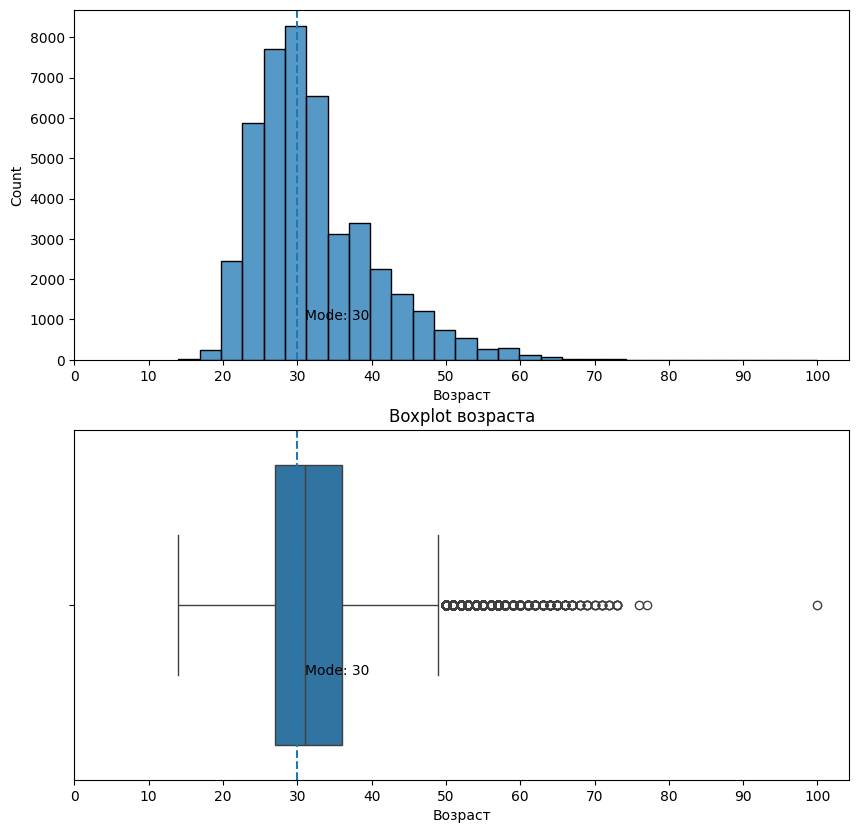

In [58]:
fig, axes = plt.subplots(nrows = 2, ncols = 1 , figsize = (10,10))
sns.histplot(
    hh_df['Возраст'],
    ax= axes[0],
    bins = 30
)

axes[0].set_title = "Гистограмма по возрасту"
axes[0].set_xticks(
    np.arange(0, hh_df['Возраст'].max() + 10, 10)
)


mode_age = hh_df['Возраст'].mode()[0]

axes[0].axvline(mode_age,linestyle='--')

axes[0].text(
    mode_age + 1,
    1000,
    f'Mode: {mode_age}'
)


# строим бокплот
sns.boxplot(
    x = hh_df['Возраст'],
    ax = axes[1]
)

axes[1].set_title('Boxplot возраста')

# одинаковые оси
axes[0].set_xticks(np.arange(0, hh_df['Возраст'].max() + 10, 10))
axes[1].set_xticks(
    np.arange(0, hh_df['Возраст'].max() + 10, 10)
)


axes[1].axvline(
    mode_age,
    linestyle='--'
)

axes[1].text(
    mode_age + 1,
    0.2,
    f'Mode: {mode_age}'
)


plt.show()

In [59]:
hh_df['Возраст'].describe()

,Возраст
count,44744.000000
mean,32.196741
std,7.929800
min,14.000000
25%,27.000000
50%,31.000000
75%,36.000000
max,100.000000


# Выводы по распределению признака "Возраст".

Мода распределения - 30 лет. Минимальное и максимальное значение возраста - от 14 до 100 лет. Возраст большинства соискателей  - от 14 до 50 лет. Старше 50 лет - в нашем датасете это аномалии, но пенсионный возраст в России сейчас 65 лет, так что точки после 50 стоит изучить подробнее. Одинокая точка после 80 - точно выброс.



2. Постройте распределение признака **"Опыт работы (месяц)"**. Опишите данное распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится опыт работы большинства соискателей? Есть ли аномалии для признака опыта работы, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

<Axes: xlabel='Опыт работы, мес'>

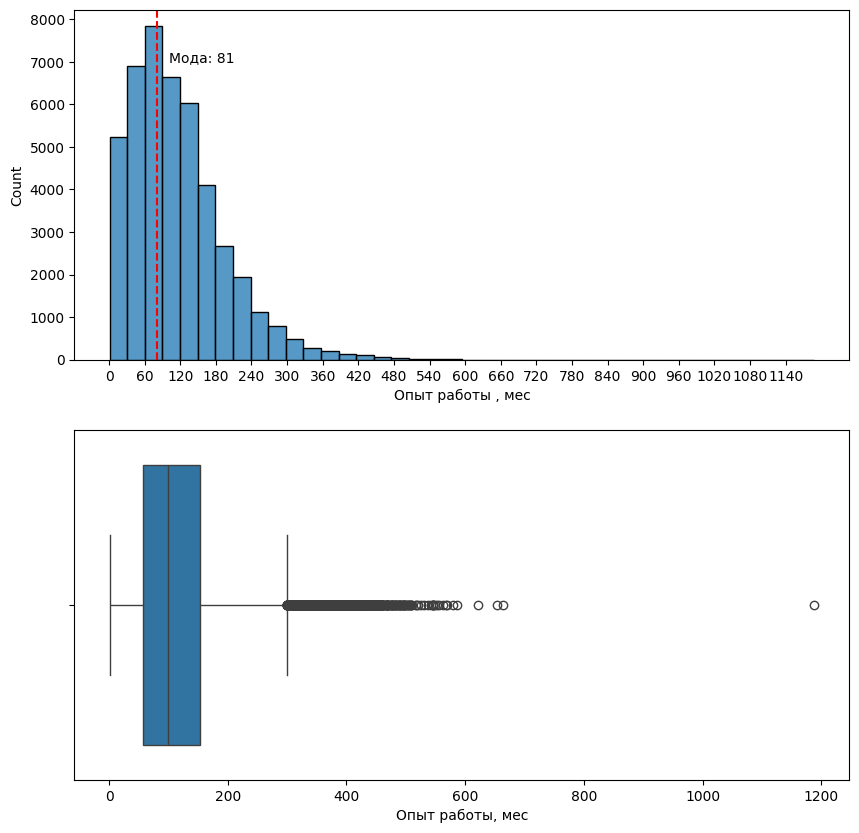

In [60]:
fig, axes = plt.subplots(nrows = 2, ncols = 1, figsize = (10,10))
hh_df['Опыт работы, лет'] = hh_df['Опыт работы, мес']/12

sns.histplot (hh_df['Опыт работы, мес'], ax = axes[0], bins = 40)
# axes[0].set_title('Гистограмма "Опыт работы , лет"')
axes[0].set_xlabel('Опыт работы , мес')
axes[0].set_xticks(
    np.arange(0, hh_df['Опыт работы, мес'].max() , 60)
)

mode_exp = hh_df['Опыт работы, мес'].mode()[0]
axes[0].axvline(mode_exp,linestyle='--', color = 'red')
axes[0].text(
    mode_exp + 20,
    7000,
    f'Мода: {int(mode_exp)}'
)

sns.boxplot(
    x = hh_df['Опыт работы, мес'],
    ax = axes[1]
)

In [61]:
mode_exp = int(hh_df['Опыт работы, мес'].mode()[0])
print(f'Мода (Опыт работы) = {mode_exp} мес')


Мода (Опыт работы) = 81 мес


Распределение признака "Опыт работы".

Чаще всего в резюме у соискателей встречается опыт работы - от 60 до 90 месяцев (или от 5 до 7,5 лет). Мода распределения - 81 месяц, или 6 лет и 9 месяцев. Предельные значения "Опыт работы" от 0 до 1140 (95 лет). Опыт работы большинства соискателей находится в промежутке от 0 до 300 месяцев(25 лет). До 600 месяцев опыта (50 лет) - точек на боксплоте еще довольно много, а вот больше уже - единичные выбросы.

3. Постройте распределение признака **"ЗП (руб)"**. Опишите данное распределение, отвечая на следующие вопросы: каковы предельные значения признака, в каком примерном интервале находится заработная плата большинства соискателей? Есть ли аномалии для признака возраста? Обратите внимание на гигантские размеры желаемой заработной платы.
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*


<Axes: xlabel='ЗП (руб)'>

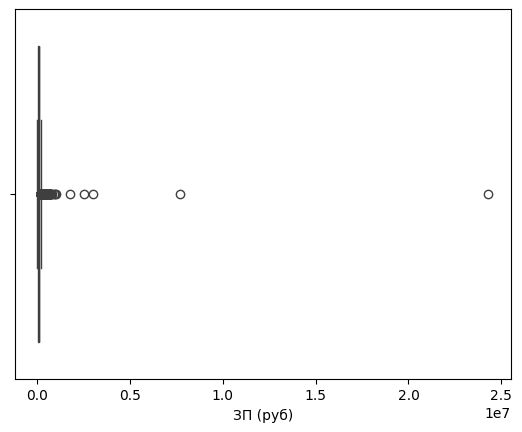

In [62]:


sns.boxplot(
    x = hh_df['ЗП (руб)']
)

# plt.xlim(0, 500000)

Из-за выброса в желаемой ЗП в 25 миллионов руб, и еще одной точки с желаемой ЗП более 5 млн руб график неинформативен. Нужно установить лимит по оси абсцисс


In [63]:
hh_df['ЗП (руб)'].describe()

,ЗП (руб)
count,4.474400e+04
mean,7.653354e+04
std,1.359315e+05
min,1.000000e+00
25%,3.708220e+04
50%,5.901900e+04
75%,9.500000e+04
max,2.430488e+07


(0.0, 1000000.0)

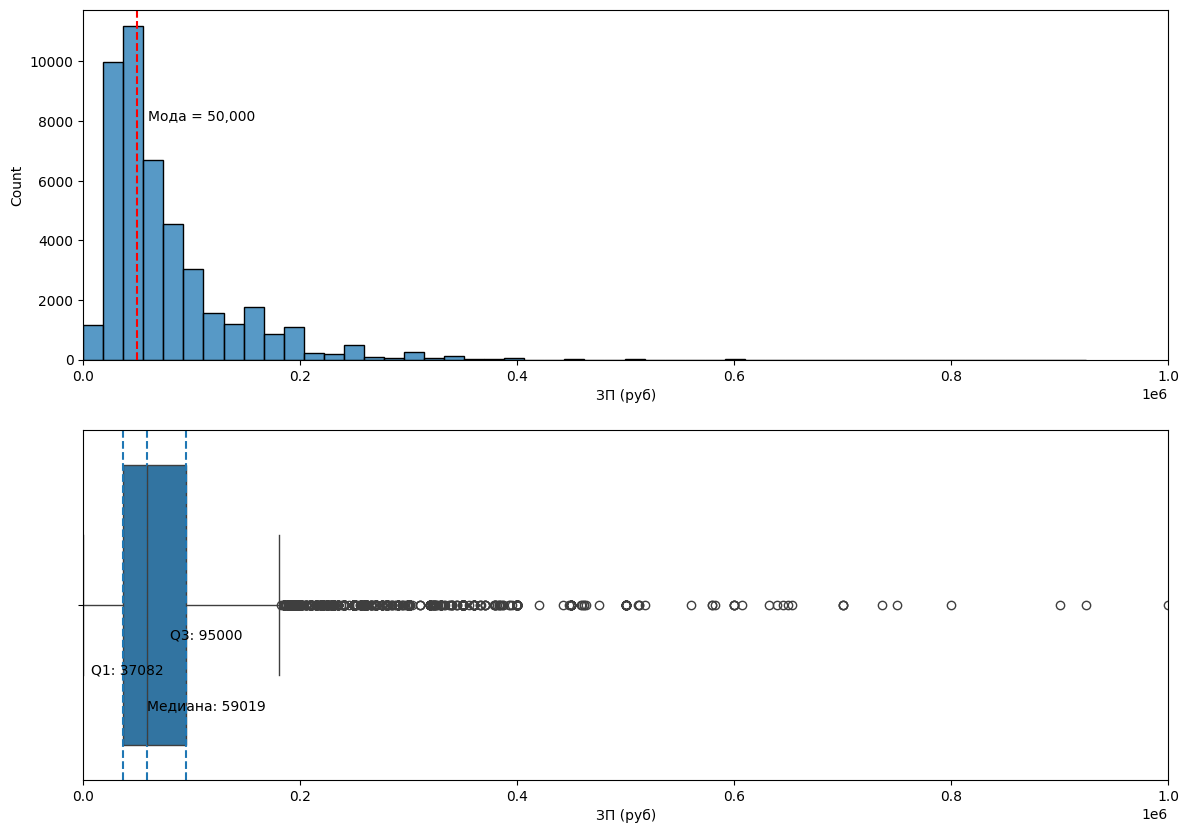

In [64]:
fig, axes = plt.subplots(nrows = 2, ncols=1, figsize = (14,10))


sns.histplot(
    hh_df[hh_df['ЗП (руб)'] < 1000000]['ЗП (руб)'],
    ax = axes[0],
    bins = 50
)

mode_ = hh_df['ЗП (руб)'].mode()[0]
axes[0].axvline(mode_,linestyle='--', color = 'red')
axes[0].text(mode_ + 10000, 8000, f'Мода = {mode_:,.0f}')

sns.boxplot(
    x = hh_df['ЗП (руб)'],
    ax = axes[1]
)

# границы ящика
q1 = hh_df['ЗП (руб)'].quantile(0.25)
median = hh_df['ЗП (руб)'].median()
q3 = hh_df['ЗП (руб)'].quantile(0.75)

# линии
axes[1].axvline(q1, linestyle='--')
axes[1].axvline(median, linestyle='--')
axes[1].axvline(q3, linestyle='--')

# подписи
axes[1].text(q1-30000, 0.2, f'Q1: {int(q1)}')
axes[1].text(median, 0.3, f'Медиана: {int(median)}')
axes[1].text(q3-15000, 0.1, f'Q3: {int(q3)}')


# лимит по оси
axes[0].set_xlim(0, 1000000)
axes[1].set_xlim(0, 1000000)

In [65]:
mode_zp = int(hh_df['ЗП (руб)'].mode()[0])
print(f'Мода (ЗП,руб) = {mode_zp} руб')

Мода (ЗП,руб) = 50000 руб


## Выводы - распределение признака "ЗП, руб"

Предельные значения признака "ЗП, руб" - от 0 до 25 млн. руб. Однако большинство значений находится в интервале от 37 тыс до 95 тысяч, медиана - 59 тысяч, мода - 50 тысяч. Точки со значениями более 800 тысяч выглядит аномалиями. 25 миллионов - явный выброс

4. Постройте диаграмму, которая показывает зависимость **медианной** желаемой заработной платы (**"ЗП (руб)"**) от уровня образования (**"Образование"**). Используйте для диаграммы данные о резюме, где желаемая заработная плата меньше 1 млн рублей.
*Сделайте выводы по представленной диаграмме: для каких уровней образования наблюдаются наибольшие и наименьшие уровни желаемой заработной платы? Как вы считаете, важен ли признак уровня образования при прогнозировании заработной платы?*

In [66]:
salary_df = hh_df[hh_df['ЗП (руб)'] < 1000000][['ЗП (руб)','Образование']]
salary_df.head()

,ЗП (руб),Образование
0,29000.0,неоконченное высшее
1,40000.0,высшее
2,20000.0,среднее специальное
3,100000.0,высшее
4,140000.0,высшее


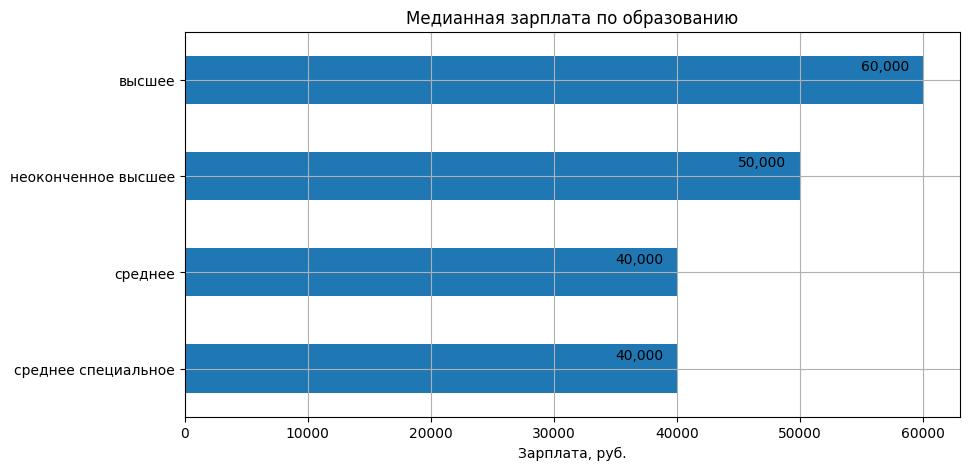

In [67]:


median_salary = hh_df[hh_df['ЗП (руб)'] < 1000000].groupby('Образование')['ЗП (руб)'].median().sort_values(ascending=True)

ax = median_salary.plot(
    kind='barh',
    figsize=(10, 5),
    grid=True
)

ax.set_title('Медианная зарплата по образованию')
ax.set_xlabel('Зарплата, руб.')
ax.set_ylabel('')



# подписи значений
for i, v in enumerate(median_salary):
    ax.text(v - 5000, i+0.1, f'{int(v):,}')

plt.show()

### Выводы по графику зависимости медианной желаемой заработной платы ("ЗП (руб)") от уровня образования ("Образование")

Уровень медианной зарплаты для высшего образования (60 тысяч) на 50% выше, чем для среднего образования (40 тысяч) и на 20% больше чем для неоконченного высшего (50 тысяч). Признак уровня образования оказывает влияние на ожидаемую заработную плату

5. Постройте диаграмму, которая показывает распределение желаемой заработной платы (**"ЗП (руб)"**) в зависимости от города (**"Город"**). Используйте для диаграммы данные о резюме, где желая заработная плата меньше 1 млн рублей.
*Сделайте выводы по полученной диаграмме: как соотносятся медианные уровни желаемой заработной платы и их размах в городах? Как вы считаете, важен ли признак города при прогнозировании заработной платы?*

In [68]:
hh_df.rename(
    columns = {'city':'Город'},
    inplace = True,
    errors = 'ignore'
)

In [69]:
order = (
    hh_df.groupby('Город')['ЗП (руб)']
    .median()
    .sort_values(ascending = False)
    .index
)
order

Index(['Москва', 'Санкт-Петербург', 'город-миллионник', 'другие'], dtype='object', name='Город')

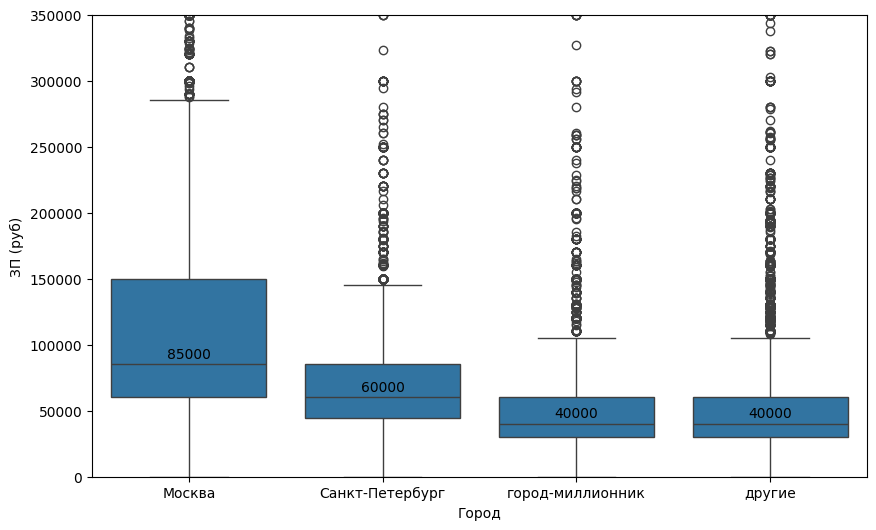

In [70]:


order = (
    hh_df.groupby('Город')['ЗП (руб)']
    .median()
    .sort_values(ascending = False)
    .index
)


plt.figure(figsize = (10,6))
ax = sns.boxplot(
      data = hh_df[hh_df['ЗП (руб)'] < 1000000],
      x = 'Город',
      y = 'ЗП (руб)',
      order = order
)

# медианы
medians = (
    hh_df[hh_df['ЗП (руб)'] < 1000000]
    .groupby('Город')['ЗП (руб)']
    .median()
)

# подписи
for i, median in enumerate(medians):
    ax.text(
        i,
        median + 5000,
        f'{int(median)}',
        ha='center'
    )



plt.ylim(0,350000)
plt.show()

In [71]:
hh_df[hh_df['ЗП (руб)'] < 1000000].groupby('Город')['ЗП (руб)'].median().sort_values(ascending=True)

,ЗП (руб)
Город,
другие,40000.0
город-миллионник,40000.0
Санкт-Петербург,60000.0
Москва,85000.0



В Москве уровень медианного уровня желаемой заработной платы и размах значительно выше чем в Питере (40%) и остальных городах (более 50%). Разброс значений также значительно больше в Москве - до 300 тысяч против 150 тысяч в Петербурге и 60 тысячах в других городах. А вот города миллионики и прочие города не имеют существенных различий в ожиданиях заработной платы. Соискатели в городах Москва и Санкт Петербург ожидают более высокой зарплаты, это важно при планировании зарплаты.

6. Постройте **многоуровневую столбчатую диаграмму**, которая показывает зависимость медианной заработной платы (**"ЗП (руб)"**) от признаков **"Готовность к переезду"** и **"Готовность к командировкам"**. Проанализируйте график, сравнив уровень заработной платы в категориях.

In [72]:
hh_df.rename(
    columns = {'relocation':'Готовность к переезду','bi_trip':'Готовность к командировкам'},
    inplace = True,
    errors = 'ignore'
)

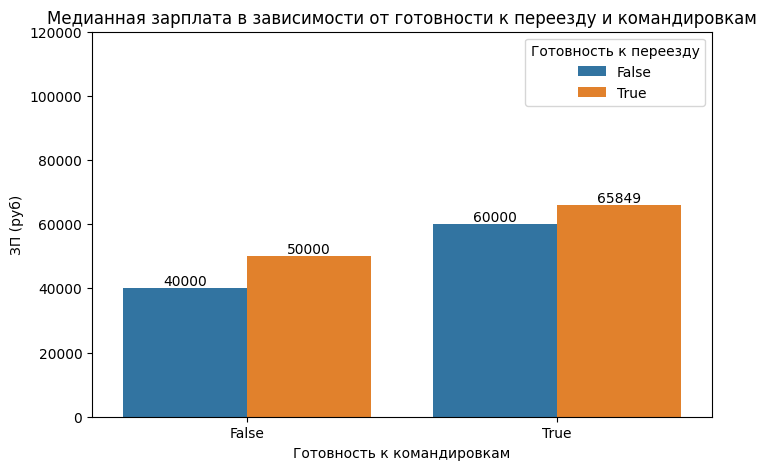

In [73]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
      data=hh_df,
      x='Готовность к командировкам',
      hue ='Готовность к переезду',
      y='ЗП (руб)',

      estimator=np.median,
      errorbar=None
)

# подписи
for container in ax.containers:
  ax.bar_label(
        container,
        fmt='%.0f'
    )


plt.ylim(0, 120000)

plt.title('Медианная зарплата в зависимости от готовности к переезду и командировкам')

plt.show()


У соискателей, готовых на переезд и командировки зарплатные ожидания на 50% выше, чем у тех соискателей кто не готов к командировкам и переезду. Готовность к командировкам повышает ожидаемый медианный уровень зарплаты на 50% и на 30% соответственно в зависимости от готовности к перезду.

7. Постройте сводную таблицу, иллюстрирующую зависимость **медианной** желаемой заработной платы от возраста (**"Возраст"**) и образования (**"Образование"**). На полученной сводной таблице постройте **тепловую карту**. Проанализируйте тепловую карту, сравнив показатели внутри групп.

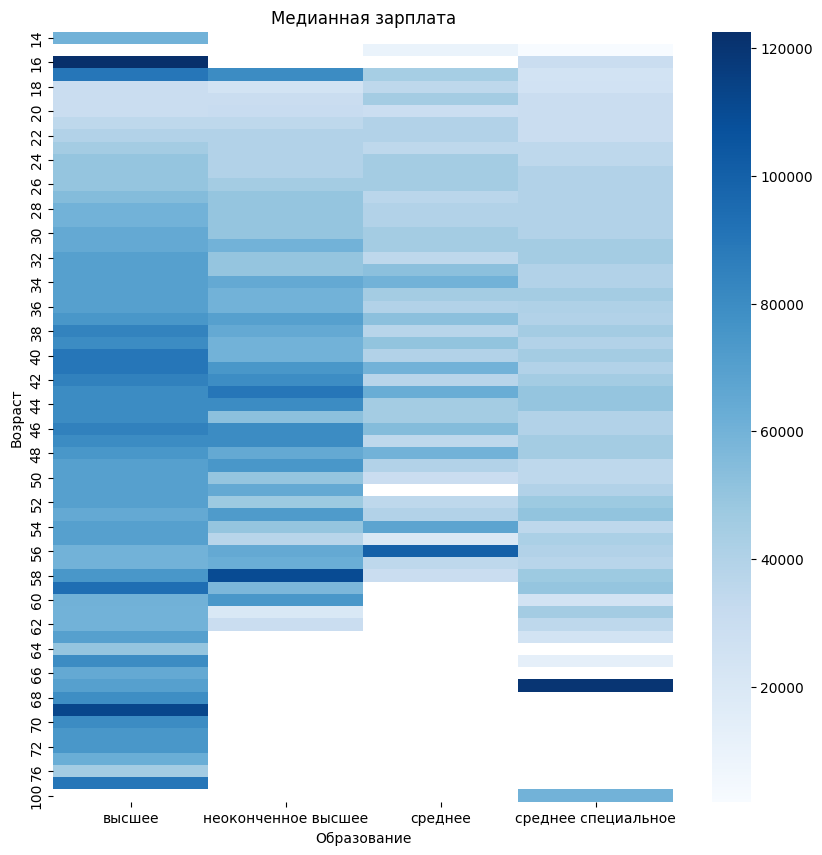

In [74]:
pivot = hh_df.pivot_table (
    values = 'ЗП (руб)',
    index = 'Возраст',
    columns = 'Образование',
    aggfunc = 'median'
)

plt.figure(figsize=(10, 10))

sns.heatmap(
    pivot,
    # annot=True,
    # fmt='.0f',
    cmap='Blues'
)

plt.title(
    'Медианная зарплата'
)

plt.show()

Самые низкие ожидания в зарплате - у соискателей со средним и средним специальным образованием. Рост зарплатных ожиданий с возрастом незначительный.

У людей с высшим образованием - в начале карьеры - низкие ожидания по зп, затем начинают расти и к возрасту - 38-45 лет достигают максимума, и далее остаются на довольно высоком уровне. Причем - вплоть до 80 лет.
В группе "неоконченное высшее" - зарплатные ожидания так же растут с возрастом, и очевидно с опытом, но медленнее чем в группе "высшее"


8. Постройте **диаграмму рассеяния**, показывающую зависимость опыта работы (**"Опыт работы (месяц)"**) от возраста (**"Возраст"**). Опыт работы переведите из месяцев в года, чтобы признаки были в едином масштабе. Постройте на графике дополнительно прямую, проходящую через точки (0, 0) и (100, 100). Данная прямая соответствует значениям, когда опыт работы равен возрасту человека. Точки, лежащие на этой прямой и выше нее - аномалии в наших данных (опыт работы больше либо равен возрасту соискателя)

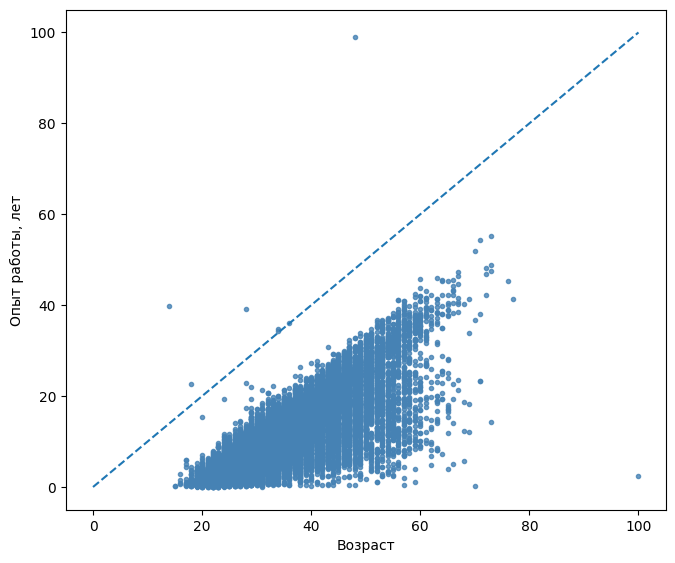

In [75]:
hh_df['Опыт работы, лет'] = hh_df['Опыт работы, мес'] / 12

fig = plt.figure(figsize = (6,5))
axes = fig.add_axes([0,0,1,1])

# colors = hh_df['Пол'].map({
#     'Мужчина': 'lightblue',
#     'Женщина': 'darkorange'
# })
colors = 'steelblue'

axes.scatter(
    x = hh_df['Возраст'],
    y = hh_df['Опыт работы, лет'],
    marker = '.',
    c = colors,
    alpha=0.8 #прозрачность
)

axes.set_xlabel('Возраст')
axes.set_ylabel('Опыт работы, лет')

axes.plot( (0,100) ,(0,100),  linestyle='--')


plt.show()

На графике построена дополнительная прямая - возраст = опыту. Точки выше этой прямой аномалии - где опыт работы больше возраста.

**Дополнительные баллы**

Для получения 2 дополнительных баллов по разведывательному анализу постройте еще два любых содержательных графика или диаграммы, которые помогут проиллюстрировать влияние признаков/взаимосвязь между признаками/распределения признаков. Приведите выводы по ним. Желательно, чтобы в анализе участвовали признаки, которые мы создавали ранее в разделе "Преобразование данных".


Построим график ожиданияуровня зарплаты в зависимости от пола соискателя


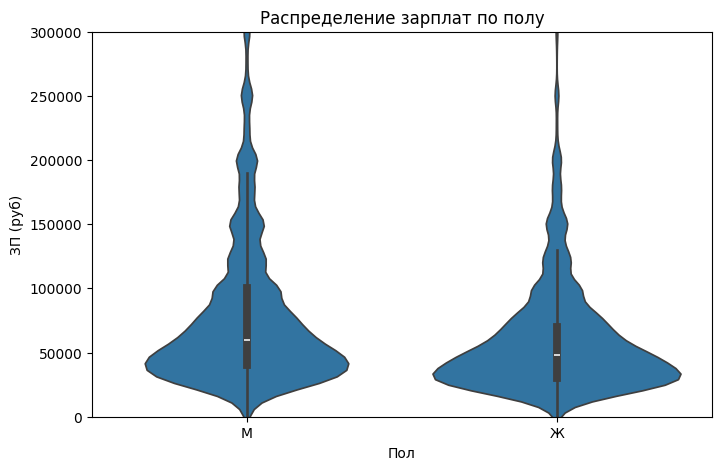

In [76]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=hh_df[hh_df['ЗП (руб)'] < 500000],
    x='Пол',
    y='ЗП (руб)'
)

plt.ylim(0, 300000)

plt.title(
    'Распределение зарплат по полу'
)

plt.show()

В целом распределение ожидаемых зарплат в зависимости от пола похожи, но у женщин - количество резюме ниже медианы является более выраженным.

### Предпочитаемый тип занятости и график работы
Посмотрим как распределены желаемые типы занятости и график работы в резюме, а также матрицу корреляций между этими признакми.



In [77]:
# считаем количество типов занятости от всех строк
employment_cols = [
    'полная занятость',
    'частичная занятость',
    'проектная работа',
    'стажировка',
    'волонтерство'

    # ,'вахтовый метод', 'полный день', 'гибкий график', 'удаленная работа', 'сменный график'
]

employment_percent = (
    hh_df[employment_cols]
    .mean()
    * 100
).sort_values(ascending=True)

hh_df.columns
graf_cols = ['вахтовый метод',
 'гибкий график',
 'полный день',
 'сменный график',
 'удаленная работа']

grafic_percent = (
    hh_df[graf_cols]
    .mean()
    * 100
).sort_values(ascending=True)

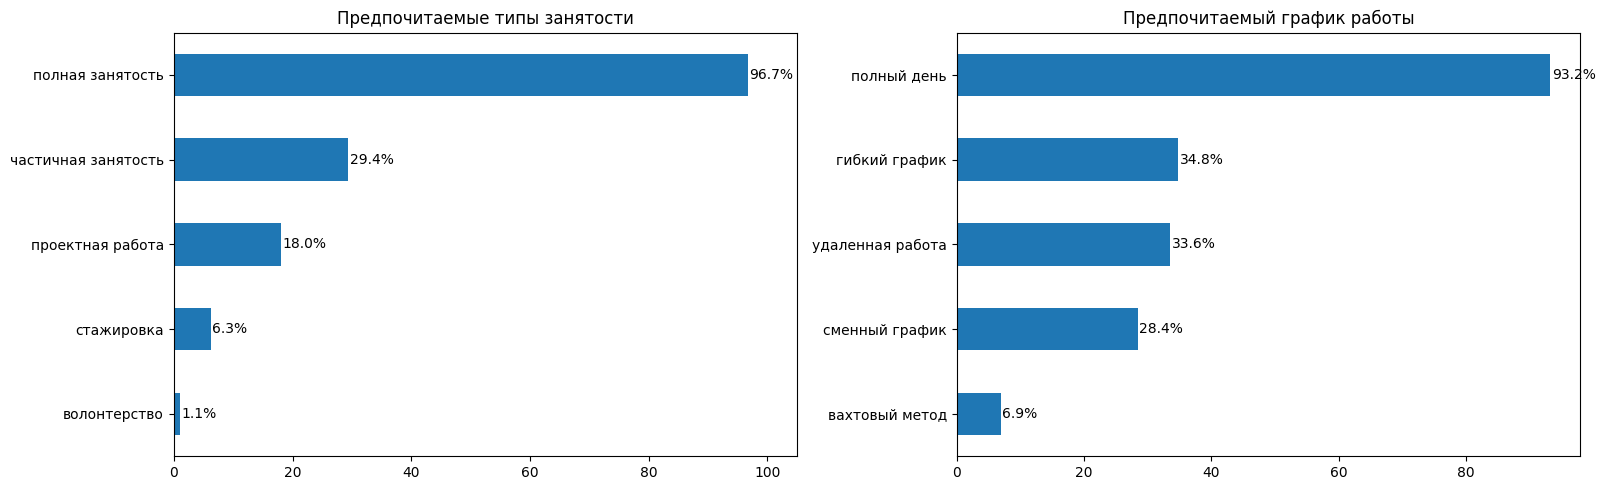

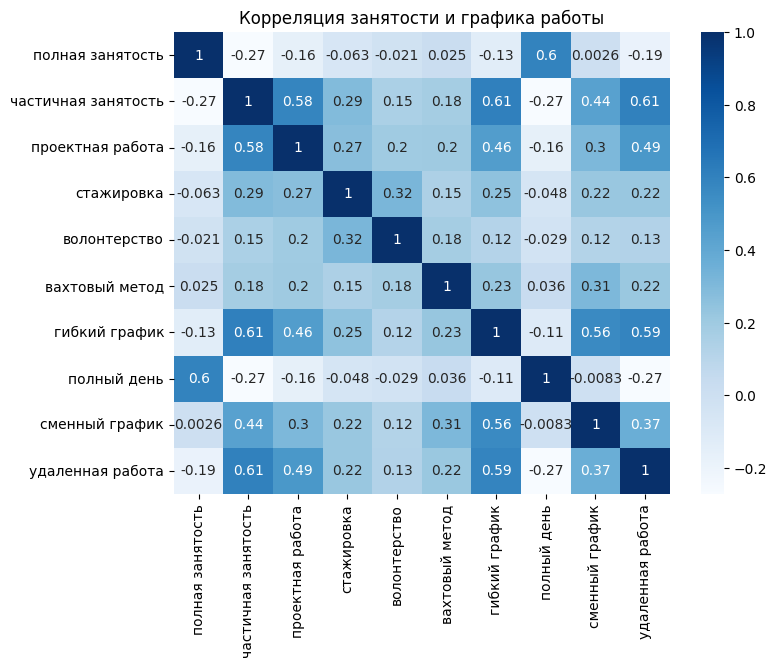

In [78]:
fig, axes = plt.subplots(1, 2,figsize=(16, 5))


# --- предпочитаемые типы занятости ---
employment_percent.plot(
    kind='barh',
    ax=axes[0]
)


axes[0].set_title('Предпочитаемые типы занятости')
axes[0].set_xlim(0,105)

# --- предпочитаемые графики работы ---
axes[1].set_title('Предпочитаемый график работы')
grafic_percent.plot(
    kind='barh',
    ax=axes[1]
)
plt.tight_layout()

# подписи для 2х графиков
for i in range (2):
  for container in axes[i].containers:
      labels = [f'{v:.1f}%' for v in container.datavalues ]

      axes[i].bar_label(
          container,
          labels=labels,
          padding= 1
      )


# матрица корреляций
corr = hh_df[employment_cols + graf_cols].corr()

corr_matrix = corr.loc[employment_cols,graf_cols]

plt.figure(figsize=(8, 6))
plt.title('Корреляция занятости и графика работы')

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues'
)



plt.show()



Большинство соискателей (≈97%) заинтересованы в полной занятости.
Таким образом, данный признак обладает низкой информативностью

Между признаками гибких форматов работы (гибкий график, удаленная работа, частичная занятость) наблюдается  сильная положительная связь (коэф корр ~ 0.6), однако признаки не являются полными дубликатами, поэтому удалять их не следует.

# Очистка данных

1. Начнем с дубликатов в наших данных. Найдите **полные дубликаты** в таблице с резюме и удалите их.

In [79]:
hh_df = hh_df.drop_duplicates()
hh_df.shape[0]

44586

2. Займемся пропусками. Выведите информацию **о числе пропусков** в столбцах.

In [80]:
missing = hh_df.isna().sum()
missing[missing>0].sort_values(ascending = False)

,0
"Опыт работы, лет",168
"Опыт работы, мес",168
Последняя/нынешняя должность,2
Последнее/нынешнее место работы,1


In [81]:
# удалим вспомогательные столбцы
# Опыт работы, лет
# experience_group

hh_df.drop(columns=['Опыт работы, лет', 'experience_group'], inplace = True, errors = 'ignore')

missing = hh_df.isna().sum()
missing[missing>0].sort_values(ascending = False)

,0
"Опыт работы, мес",168
Последняя/нынешняя должность,2
Последнее/нынешнее место работы,1


In [82]:
# hh_df[
#     hh_df['experience_group'].isna()
# ]

3. Итак, у нас есть пропуски в 3ех столбцах: **"Опыт работы (месяц)"**, **"Последнее/нынешнее место работы"**, **"Последняя/нынешняя должность"**. Поступим следующим образом: удалите строки, где есть пропуск в столбцах с местом работы и должностью. Пропуски в столбце с опытом работы заполните **медианным** значением.

In [83]:
hh_df = hh_df.dropna( subset = ['Последняя/нынешняя должность', 'Последнее/нынешнее место работы'])
missing = hh_df.isna().sum()
missing[missing>0].sort_values(ascending = False)

,0
"Опыт работы, мес",168


In [84]:
median_exp = hh_df['Опыт работы, мес'].median()
hh_df = hh_df.fillna({
    'Опыт работы, мес': median_exp
})

# hh_df.isna().sum()

4. Мы добрались до ликвидации выбросов. Сначала очистим данные вручную. Удалите резюме, в которых указана заработная плата либо выше 1 млн. рублей, либо ниже 1 тыс. рублей.

In [85]:
print(f'Количество строк ДО удаления: {hh_df.shape[0]}')
# hh_df[(hh_df['ЗП (руб)'] <= 1000000) & (hh_df['ЗП (руб)'] >= 1000) ].shape

hh_df = hh_df[(hh_df['ЗП (руб)'] <= 1000000) & (hh_df['ЗП (руб)'] >= 1000) ]
print(f'Количество строк ПОСЛЕ удаления: {hh_df.shape[0]}')

Количество строк ДО удаления: 44584
Количество строк ПОСЛЕ удаления: 44495


5. В процессе разведывательного анализа мы обнаружили резюме, в которых **опыт работы в годах превышал возраст соискателя**. Найдите такие резюме и удалите их из данных


In [86]:


hh_df = hh_df[hh_df['Возраст'] > (hh_df['Опыт работы, мес'] / 12)]
print(f'Количество строк ПОСЛЕ удаления: {hh_df.shape[0]}')

Количество строк ПОСЛЕ удаления: 44488


6. В результате анализа мы обнаружили потенциальные выбросы в признаке **"Возраст"**. Это оказались резюме людей чересчур преклонного возраста для поиска работы. Попробуйте построить распределение признака в **логарифмическом масштабе**. Добавьте к графику линии, отображающие **среднее и границы интервала метода трех сигм**. Напомним, сделать это можно с помощью метода axvline. Например, для построение линии среднего будет иметь вид:

`histplot.axvline(log_age.mean(), color='k', lw=2)`

В какую сторону асимметрично логарифмическое распределение? Напишите об этом в комментарии к графику.
Найдите выбросы с помощью метода z-отклонения и удалите их из данных, используйте логарифмический масштаб. Давайте сделаем послабление на **1 сигму** (возьмите 4 сигмы) в **правую сторону**.

Выведите таблицу с полученными выбросами и оцените, с каким возрастом соискатели попадают под категорию выбросов?

In [87]:
# среднее и сигмы на логарифмах
log_age = np.log(hh_df['Возраст'])

mu = log_age.mean()
sigma = log_age.std()


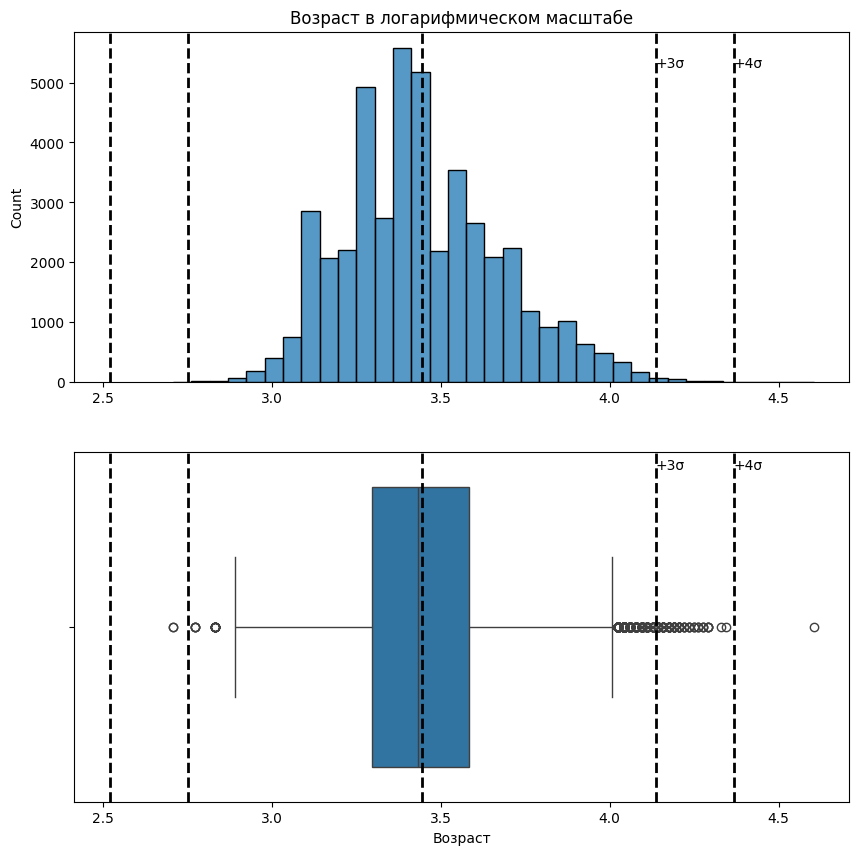

На графике добавлены линии среднего значения, а также границы допустимых значений по правилу сигм для +3σ и +4σ.


In [88]:
fig, axes = plt.subplots(nrows = 2, ncols = 1 , figsize = (10,10), sharex=True)

sns.histplot(
    np.log(hh_df['Возраст']),
    ax = axes[0],
    bins = 35
)

axes[0].set_title(
    'Возраст в логарифмическом масштабе'
)
axes[0].tick_params(labelbottom=True)

# строим бокплот
sns.boxplot(
    x = np.log(hh_df['Возраст']),
    ax = axes[1]
)



for i in range(2):
  # среднее
  axes[i].axvline((mu), linestyle='--', label='mean', color='k', lw=2)
  # 3 сигмы
  axes[i].axvline((mu + 3*sigma) , linestyle='--', color='k', lw=2)
  axes[i].axvline((mu - 3*sigma) , linestyle='--', color='k', lw=2)

  axes[i].text(
        mu + 3*sigma ,
        axes[i].get_ylim()[1] * 0.9,
        '+3σ'
    )


    # 4 сигмы
  axes[i].axvline((mu + 4*sigma) , linestyle='--', color='k', lw=2)
  axes[i].axvline((mu - 4*sigma) , linestyle='--', color='k', lw=2)

  axes[i].text(
        mu + 4*sigma,
        axes[i].get_ylim()[1] * 0.9,
        '+4σ'
    )


plt.show()
print ('На графике добавлены линии среднего значения, а также границы допустимых значений по правилу сигм для +3σ и +4σ.')

In [89]:
# выведем границы возрастов при 3σ и 4σ
result = pd.DataFrame({

    'Правило σ': ['3σ', '4σ'],

    'Мин возраст': [
        np.exp(mu - 3*sigma),
        np.exp(mu - 4*sigma)
    ],

    'Макс возраст': [
        np.exp(mu + 3*sigma),
        np.exp(mu + 4*sigma)
    ]
}).round(1)

print(result)

  Правило σ  Мин возраст  Макс возраст
0        3σ         15.7          62.6
1        4σ         12.4          78.9


In [90]:
# проверим какой возраст выходит за границу -3сигма и +4 сигма
hh_df[(np.log(hh_df['Возраст']) > mu + 4*sigma)| (np.log(hh_df['Возраст']) < mu - 3*sigma)]

,ЗП,Ищет работу на должность:,Последнее/нынешнее место работы,Последняя/нынешняя должность,Обновление резюме,Авто,Образование,Пол,Возраст,"Опыт работы, мес",...,проектная работа,стажировка,полная занятость,сменный график,гибкий график,удаленная работа,вахтовый метод,полный день,date,ЗП (руб)
31137,10000 руб.,Менеджер по работе с клиентами,"ООО ""ФёрстКэшКомпани""",Менеджер по работе с клиентами,06.04.2019 09:13,Не указано,среднее,М,15,2.0,...,False,False,False,True,True,True,False,False,2019-04-06,10000.0
32950,2000 руб.,Тестировщик игр,OOO ЖМЫХ,Тестировщик ПО,09.04.2019 16:02,Не указано,среднее специальное,М,15,3.0,...,False,False,True,False,False,False,False,True,2019-04-09,2000.0
33654,60000 руб.,Frontend-разработчик,Freelance,Frontend-разработчик,19.04.2019 23:27,Не указано,среднее специальное,М,100,30.0,...,True,True,True,False,True,True,False,True,2019-04-19,60000.0


In [91]:
# оставляем только те строки , где возраст не выходит за 4 сигма
hh_df = hh_df[(np.log(hh_df['Возраст']) < mu + 4*sigma)& (np.log(hh_df['Возраст']) > mu - 3*sigma)]
print(hh_df.shape)

(44485, 25)


 ### Для поиска выбросов по признаку «Возраст» был использован метод z-отклонения.
 Логарифмическое распределение ассимитрично вправо, однако логарифмирование позволило сделать распределение более близким к нормальному и уменьшить влияние экстремальных значений.
 Далее были определены границы допустимых значений по правилу сигм. В качестве выбросов рассматривались наблюдения, выходящие за пределы интервала: мю - 3 сигмы и  мю + 4 сигмы.
 Границы получились от 15.7 лет - до 78.9 лет.